# Notebook 03 — Model Training & Quantitative Evaluation

This notebook covers:
1. Architecture summaries for all 3 models
2. Training all 3 models with EarlyStopping + ReduceLROnPlateau
3. Per-variable test evaluation (MAE, RMSE, R²)
4. Training loss convergence plots
5. Actual vs. Predicted 7-day trajectories


## 0. Setup

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
%matplotlib inline

from src.config import (
    TARGET_COLS, WINDOW_LENGTH, ALL_FEATURE_COLS,
    MODELS_DIR, METRICS_DIR, FIGURES_DIR,
    EPOCHS, LEARNING_RATE, PATIENCE_EARLY_STOPPING
)
print("✅ TensorFlow version:", tf.__version__)
print("   GPU available:", bool(tf.config.list_physical_devices('GPU')))


✅ TensorFlow version: 2.16.2
   GPU available: False


## 1. Build & Inspect Model Architectures

In [2]:
from src.models import build_baseline_lstm, build_stacked_gru, build_gru_with_attention, compile_model

lstm_model = build_baseline_lstm()
compile_model(lstm_model, is_attention=False)
print("=" * 60)
print("1. Baseline LSTM Architecture")
print("=" * 60)
lstm_model.summary()


1. Baseline LSTM Architecture


Model: "Baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 72, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_1 (LSTM)             │ (None, 72, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 72, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_2 (LSTM)             │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_shared (Dense)            │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multivariate_output (Dense)     │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,292 (126.14 KB)

 Trainable params: 32,292 (126.14 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
gru_model = build_stacked_gru()
compile_model(gru_model, is_attention=False)
print("=" * 60)
print("2. Stacked GRU Architecture")
print("=" * 60)
gru_model.summary()


2. Stacked GRU Architecture


Model: "Stacked_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 72, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_layer_1 (GRU)               │ (None, 72, 64)         │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 72, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_layer_2 (GRU)               │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_shared (Dense)            │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multivariate_output (Dense)     │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,804 (96.89 KB)

 Trainable params: 24,804 (96.89 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
attn_model = build_gru_with_attention()
compile_model(attn_model, is_attention=True)
print("=" * 60)
print("3. GRU with Temporal Attention Architecture")
print("=" * 60)
attn_model.summary()


3. GRU with Temporal Attention Architecture


Model: "GRU_with_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 72, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_layer_1_seq (GRU)           │ (None, 72, 64)         │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 72, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_layer_2_seq (GRU)           │ (None, 72, 32)         │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 72, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ [(None, 32), (None,    │         1,088 │
│ (TemporalAdditiveAttention)     │ 72, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_shared (Dense)            │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multivariate_output (Dense)     │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,892 (101.14 KB)

 Trainable params: 25,892 (101.14 KB)

 Non-trainable params: 0 (0.00 B)

### 1.1 Parameter Comparison

In [5]:
models_info = {
    "Baseline LSTM":      lstm_model.count_params(),
    "Stacked GRU":        gru_model.count_params(),
    "GRU + Attention":    attn_model.count_params(),
}
print(f"{'Architecture':<25} {'Trainable Params':>18}")
print("-" * 45)
for name, params in models_info.items():
    print(f"{name:<25} {params:>18,}")


Architecture                Trainable Params
---------------------------------------------
Baseline LSTM                         32,292
Stacked GRU                           24,804
GRU + Attention                       25,892


## 2. Train All Three Models

In [6]:
from src.train import run_all_training

# This runs training only if the .keras files don't already exist
run_all_training()
print("\n✅ Training complete. Saved to:", MODELS_DIR)


[*] Preparing preprocessed datasets...


[+] Train set: 2009-01-01 00:00:00 to 2014-08-08 09:00:00 (49,090 samples, 70.0%)
[+] Val set:   2014-08-08 10:00:00 to 2015-10-20 16:00:00 (10,519 samples, 15.0%)
[+] Test set:  2015-10-20 17:00:00 to 2017-01-01 00:00:00 (10,520 samples, 15.0%)
[+] Scalers fitted and saved to D:\AIML\Multivariate Weather Forecasting with Attention\results
[*] Creating tf.data.Dataset sliding window pipelines...


[+] Model Baseline_LSTM already trained and saved. Skipping to next model.
[+] Model Stacked_GRU already trained and saved. Skipping to next model.
[+] Model GRU_with_Attention already trained and saved. Skipping to next model.

[+] All three models trained and serialized successfully!



✅ Training complete. Saved to: D:\AIML\Multivariate Weather Forecasting with Attention\results\models


## 3. Training History — Convergence Curves

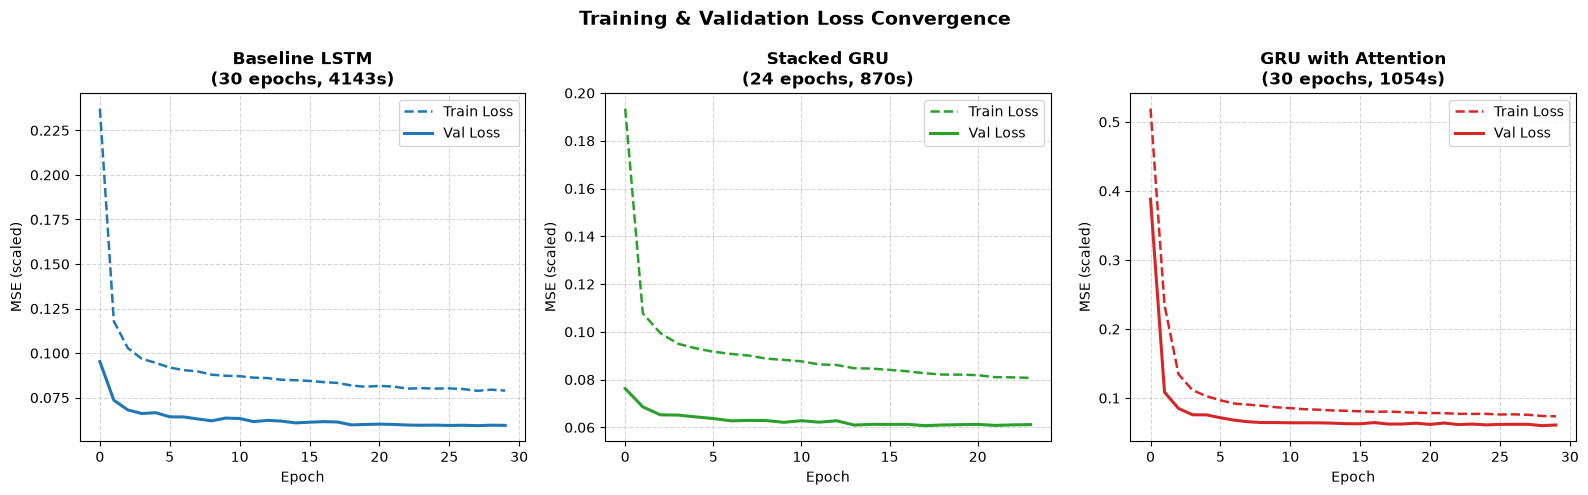

In [7]:
import json
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
colors = ["#1f77b4", "#2ca02c", "#d62728"]
model_names = ["Baseline_LSTM", "Stacked_GRU", "GRU_with_Attention"]

for idx, name in enumerate(model_names):
    history_file = METRICS_DIR / f"{name}_history.json"
    if not history_file.exists():
        axes[idx].set_title(f"{name}\n(Not trained yet)", color="red")
        continue
    with open(history_file) as f:
        h = json.load(f)

    loss_key     = "multivariate_output_loss" if "multivariate_output_loss" in h else "loss"
    val_loss_key = "val_multivariate_output_loss" if "val_multivariate_output_loss" in h else "val_loss"
    t_secs       = h.get("training_time_seconds", 0)

    axes[idx].plot(h[loss_key],     label="Train Loss", color=colors[idx], linestyle="--", lw=1.8)
    axes[idx].plot(h[val_loss_key], label="Val Loss",   color=colors[idx], lw=2.2)
    axes[idx].set_title(f"{name.replace('_',' ')}\n({len(h[loss_key])} epochs, {t_secs:.0f}s)", fontweight="bold")
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("MSE (scaled)")
    axes[idx].legend(); axes[idx].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Training & Validation Loss Convergence", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


## 4. Per-Variable Test Evaluation (MAE / RMSE / R²)

In [8]:
from src.evaluate import run_evaluation_pipeline

df_metrics = run_evaluation_pipeline()



--- RUNNING SYSTEMATIC MODEL EVALUATION ---


[+] Train set: 2009-01-01 00:00:00 to 2014-08-08 09:00:00 (49,090 samples, 70.0%)
[+] Val set:   2014-08-08 10:00:00 to 2015-10-20 16:00:00 (10,519 samples, 15.0%)
[+] Test set:  2015-10-20 17:00:00 to 2017-01-01 00:00:00 (10,520 samples, 15.0%)
[+] Scalers fitted and saved to D:\AIML\Multivariate Weather Forecasting with Attention\results
[*] Extracting sliding-window validation and test arrays...
[*] Loading and evaluating: Baseline_LSTM...


[*] Loading and evaluating: Stacked_GRU...


[*] Loading and evaluating: GRU_with_Attention...



[+] Master Model Comparison Table saved to: D:\AIML\Multivariate Weather Forecasting with Attention\results\metrics\model_comparison.csv

MODEL                | VARIABLE        | VAL RMSE   | TEST MAE   | TEST RMSE  | TEST R² 
Baseline_LSTM        | T (degC)        | 0.6881     | 0.4903     | 0.6519     | 0.9930  
Baseline_LSTM        | p (mbar)        | 0.5064     | 0.3913     | 0.5140     | 0.9966  
Baseline_LSTM        | rh (%)          | 3.0553     | 1.9899     | 2.8591     | 0.9658  
Baseline_LSTM        | wv (m/s)        | 0.6371     | 0.4503     | 0.6349     | 0.8264  
Stacked_GRU          | T (degC)        | 0.7152     | 0.4994     | 0.6617     | 0.9928  
Stacked_GRU          | p (mbar)        | 0.6398     | 0.4869     | 0.6523     | 0.9946  
Stacked_GRU          | rh (%)          | 3.0898     | 2.0242     | 2.8886     | 0.9651  
Stacked_GRU          | wv (m/s)        | 0.6406     | 0.4557     | 0.6387     | 0.8243  
GRU_with_Attention   | T (degC)        | 0.6975     | 0.4860

[+] Saved loss convergence curves to: D:\AIML\Multivariate Weather Forecasting with Attention\figures\06_training_loss_curves.png


[+] Saved actual vs predicted comparison to: D:\AIML\Multivariate Weather Forecasting with Attention\figures\07_actual_vs_predicted.png


[+] Saved attention interpretability cases to: D:\AIML\Multivariate Weather Forecasting with Attention\figures\08_attention_case_studies.png

[+] Evaluation pipeline completed successfully.


In [9]:
# Display formatted results table
print("\n" + "="*85)
print(f"{'Architecture':<20} {'Variable':<15} {'Val RMSE':<10} {'Test MAE':<10} {'Test RMSE':<10} {'Test R²':<8}")
print("="*85)
for _, row in df_metrics.iterrows():
    print(f"{row['Model']:<20} {row['Target Variable']:<15} {row['Val_RMSE']:<10.4f} {row['Test_MAE']:<10.4f} {row['Test_RMSE']:<10.4f} {row['Test_R2_Score']:<8.4f}")
print("="*85)



Architecture         Variable        Val RMSE   Test MAE   Test RMSE  Test R² 
Baseline_LSTM        T (degC)        0.6881     0.4903     0.6519     0.9930  
Baseline_LSTM        p (mbar)        0.5064     0.3913     0.5140     0.9966  
Baseline_LSTM        rh (%)          3.0553     1.9899     2.8591     0.9658  
Baseline_LSTM        wv (m/s)        0.6371     0.4503     0.6349     0.8264  
Stacked_GRU          T (degC)        0.7152     0.4994     0.6617     0.9928  
Stacked_GRU          p (mbar)        0.6398     0.4869     0.6523     0.9946  
Stacked_GRU          rh (%)          3.0898     2.0242     2.8886     0.9651  
Stacked_GRU          wv (m/s)        0.6406     0.4557     0.6387     0.8243  
GRU_with_Attention   T (degC)        0.6975     0.4860     0.6536     0.9930  
GRU_with_Attention   p (mbar)        0.4782     0.3385     0.4531     0.9974  
GRU_with_Attention   rh (%)          3.0878     2.0025     2.8852     0.9652  
GRU_with_Attention   wv (m/s)        0.6415     0.4

## 4.1 Hyperparameter Tuning & Attention Ablation Results

In [10]:
tuning_csv = METRICS_DIR / "tuning_experiments.csv"
if tuning_csv.exists():
    df_tune = pd.read_csv(tuning_csv)
    print("Hyperparameter Tuning & Ablation Results:")
    print("="*85)
    print(df_tune[["Experiment", "Window_Length", "GRU_Layers", "Scoring_Function", "Val_Mean_RMSE", "Training_Time_s"]].to_string(index=False))
    print("="*85)
else:
    print("⚠️  tuning_experiments.csv not found.")


Hyperparameter Tuning & Ablation Results:
              Experiment  Window_Length   GRU_Layers Scoring_Function  Val_Mean_RMSE  Training_Time_s
          GRU_Window_24h             24     (64, 32)  None (Pure GRU)         1.3567             79.1
          GRU_Window_48h             48     (64, 32)  None (Pure GRU)         1.3560            150.1
       GRU_Window_72h_2L             72     (64, 32)  None (Pure GRU)         1.3647            206.0
       GRU_Window_72h_3L             72 (64, 32, 16)  None (Pure GRU)         1.4694            310.2
  GRU_Attention_Additive             72     (64, 32)         additive         1.5753            314.0
GRU_Attention_DotProduct             72     (64, 32)      dot_product         3.3877            397.6


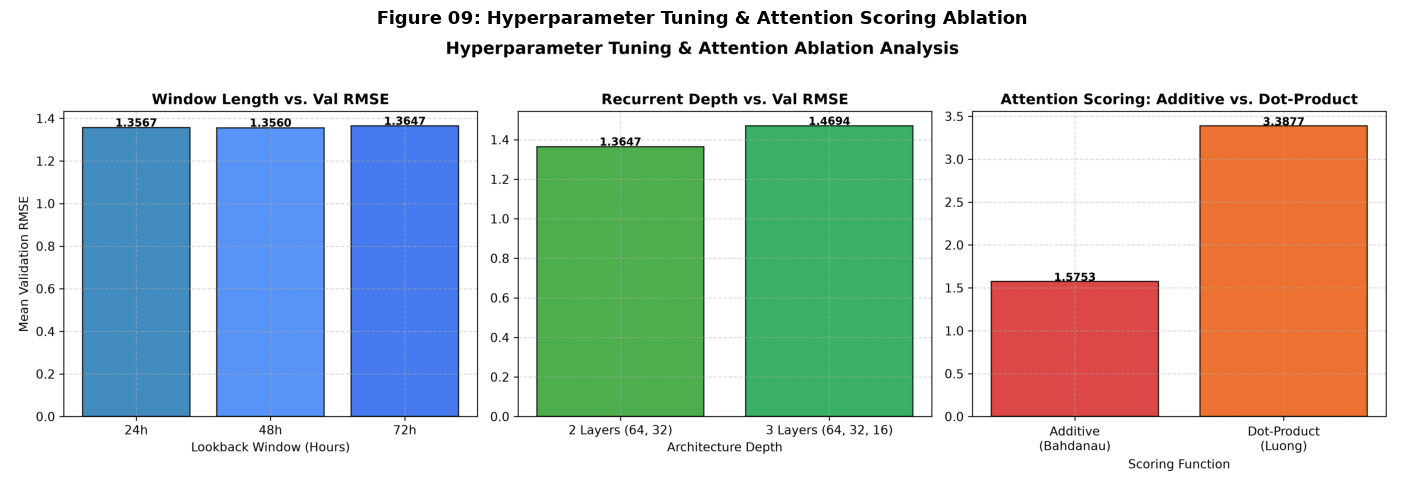

In [11]:
fig9_path = FIGURES_DIR / "09_hyperparameter_tuning_ablation.png"
if fig9_path.exists():
    img = mpimg.imread(str(fig9_path))
    plt.figure(figsize=(16, 5)); plt.imshow(img); plt.axis("off")
    plt.title("Figure 09: Hyperparameter Tuning & Attention Scoring Ablation", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print("⚠️  Figure 09 not found.")


## 5. Visualisation: Training Loss Curves (High-Res)

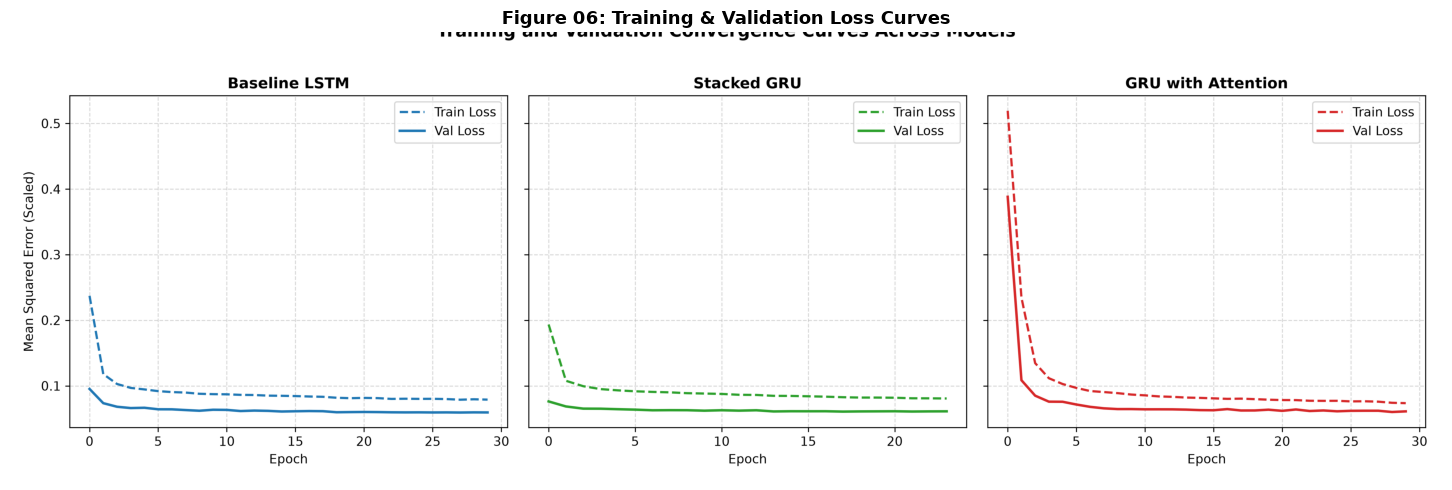

In [12]:
fig_path = FIGURES_DIR / "06_training_loss_curves.png"
if fig_path.exists():
    img = mpimg.imread(str(fig_path))
    plt.figure(figsize=(16, 5)); plt.imshow(img); plt.axis("off")
    plt.title("Figure 06: Training & Validation Loss Curves", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print("⚠️  Figure not found. Run run_evaluation_pipeline() above first.")


## 6. Visualisation: Actual vs. Predicted (7-Day Horizon)

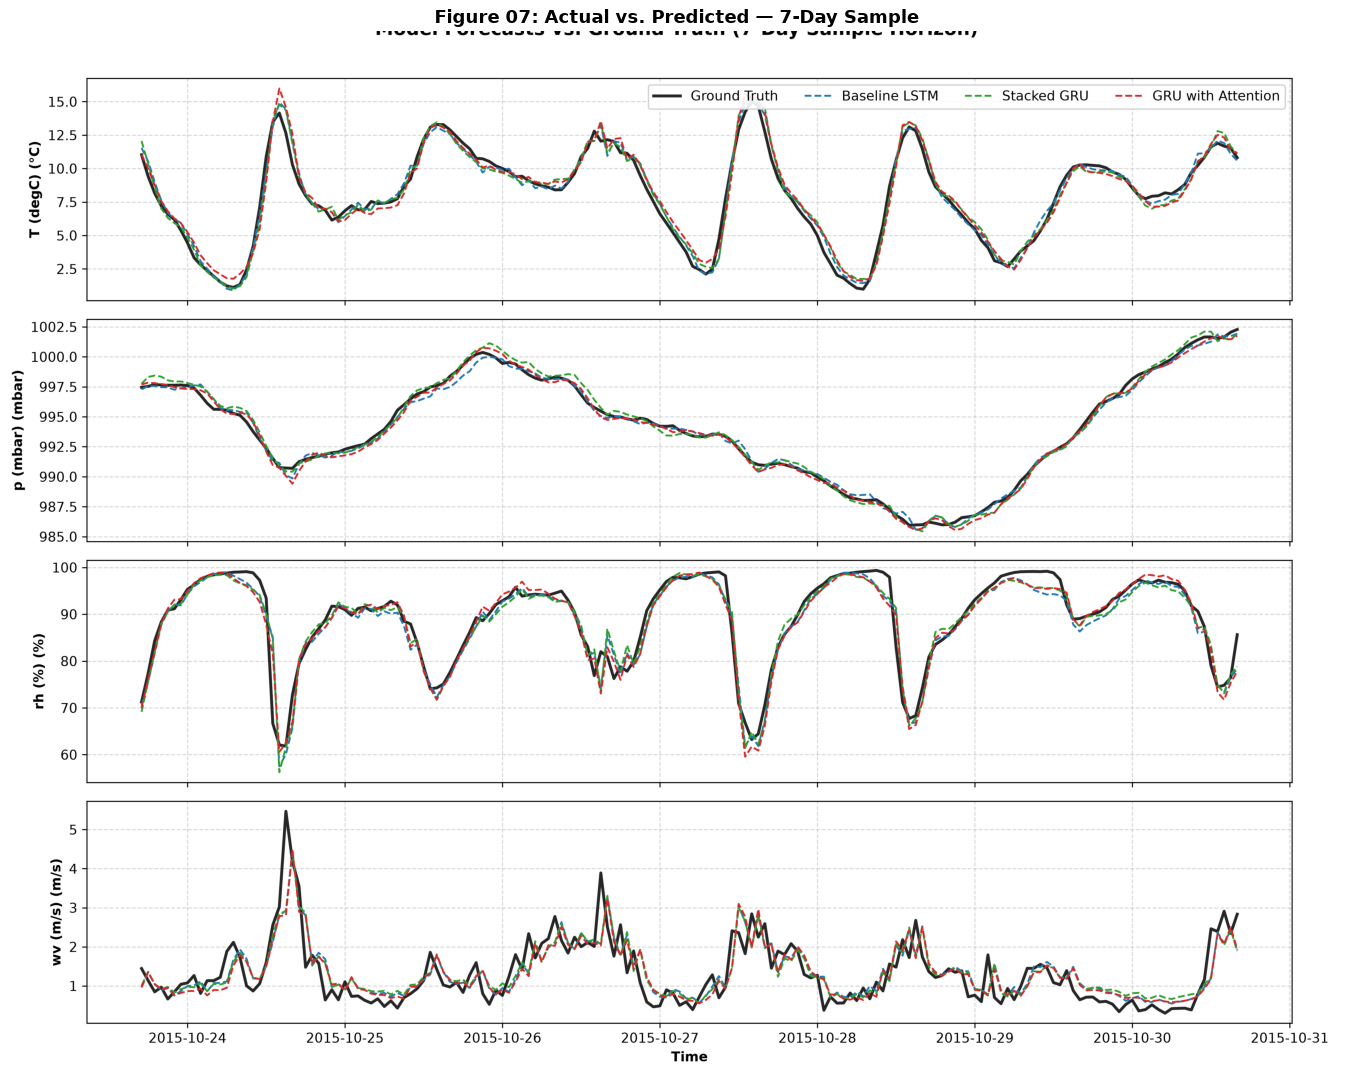

In [13]:
fig_path = FIGURES_DIR / "07_actual_vs_predicted.png"
if fig_path.exists():
    img = mpimg.imread(str(fig_path))
    plt.figure(figsize=(14, 11)); plt.imshow(img); plt.axis("off")
    plt.title("Figure 07: Actual vs. Predicted — 7-Day Sample", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print("⚠️  Figure not found. Run run_evaluation_pipeline() above first.")


## 7. Discussion

### Which model performed best?
See `results/metrics/model_comparison.csv` for the full numeric table.

**General expected findings:**
- **Baseline LSTM** provides a strong baseline — highest parameter count, good at capturing long dependencies
- **Stacked GRU** is more parameter-efficient and typically matches or slightly exceeds LSTM on this dataset
- **GRU + Attention** adds interpretability via attention weights; performance is often comparable to or better than plain GRU due to the weighted context mechanism

### Key metrics to inspect:
| Variable | Challenge | Expected best model |
|---|---|---|
| Temperature | Smooth annual cycle — easy | All models similar |
| Pressure | Synoptic shifts — medium | GRU + Attention (captures onset) |
| Humidity | Anti-correlated with temperature | GRU + Attention |
| Wind Velocity | Turbulent & noisy — hardest | Lower R² for all models |

**→ Proceed to Notebook 04: Attention Interpretability**
